In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [2]:
model_path = "../models/best_yolo8n_ball-detection.pt"
model = YOLO(model_path)

In [3]:
video_path = "../input_video/08fd33_4.mp4"

cap = cv2.VideoCapture(video_path)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
num_samples = 10  # ganti jadi 5 kalau mau lebih sedikit

# Ambil frame secara merata
frame_indices = np.linspace(0, total_frames - 1, num_samples, dtype=int)

frames = []

for idx in frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

cap.release()

print(f"Berhasil ambil {len(frames)} frame")

Berhasil ambil 10 frame


In [4]:
results = model(frames, imgsz=1280, conf=0.25)


0: 736x1280 1 ball, 257.5ms
1: 736x1280 1 ball, 257.5ms
2: 736x1280 2 balls, 257.5ms
3: 736x1280 1 ball, 257.5ms
4: 736x1280 1 ball, 257.5ms
5: 736x1280 1 ball, 257.5ms
6: 736x1280 1 ball, 257.5ms
7: 736x1280 (no detections), 257.5ms
8: 736x1280 (no detections), 257.5ms
9: 736x1280 1 ball, 257.5ms
Speed: 22.6ms preprocess, 257.5ms inference, 1.2ms postprocess per image at shape (1, 3, 736, 1280)


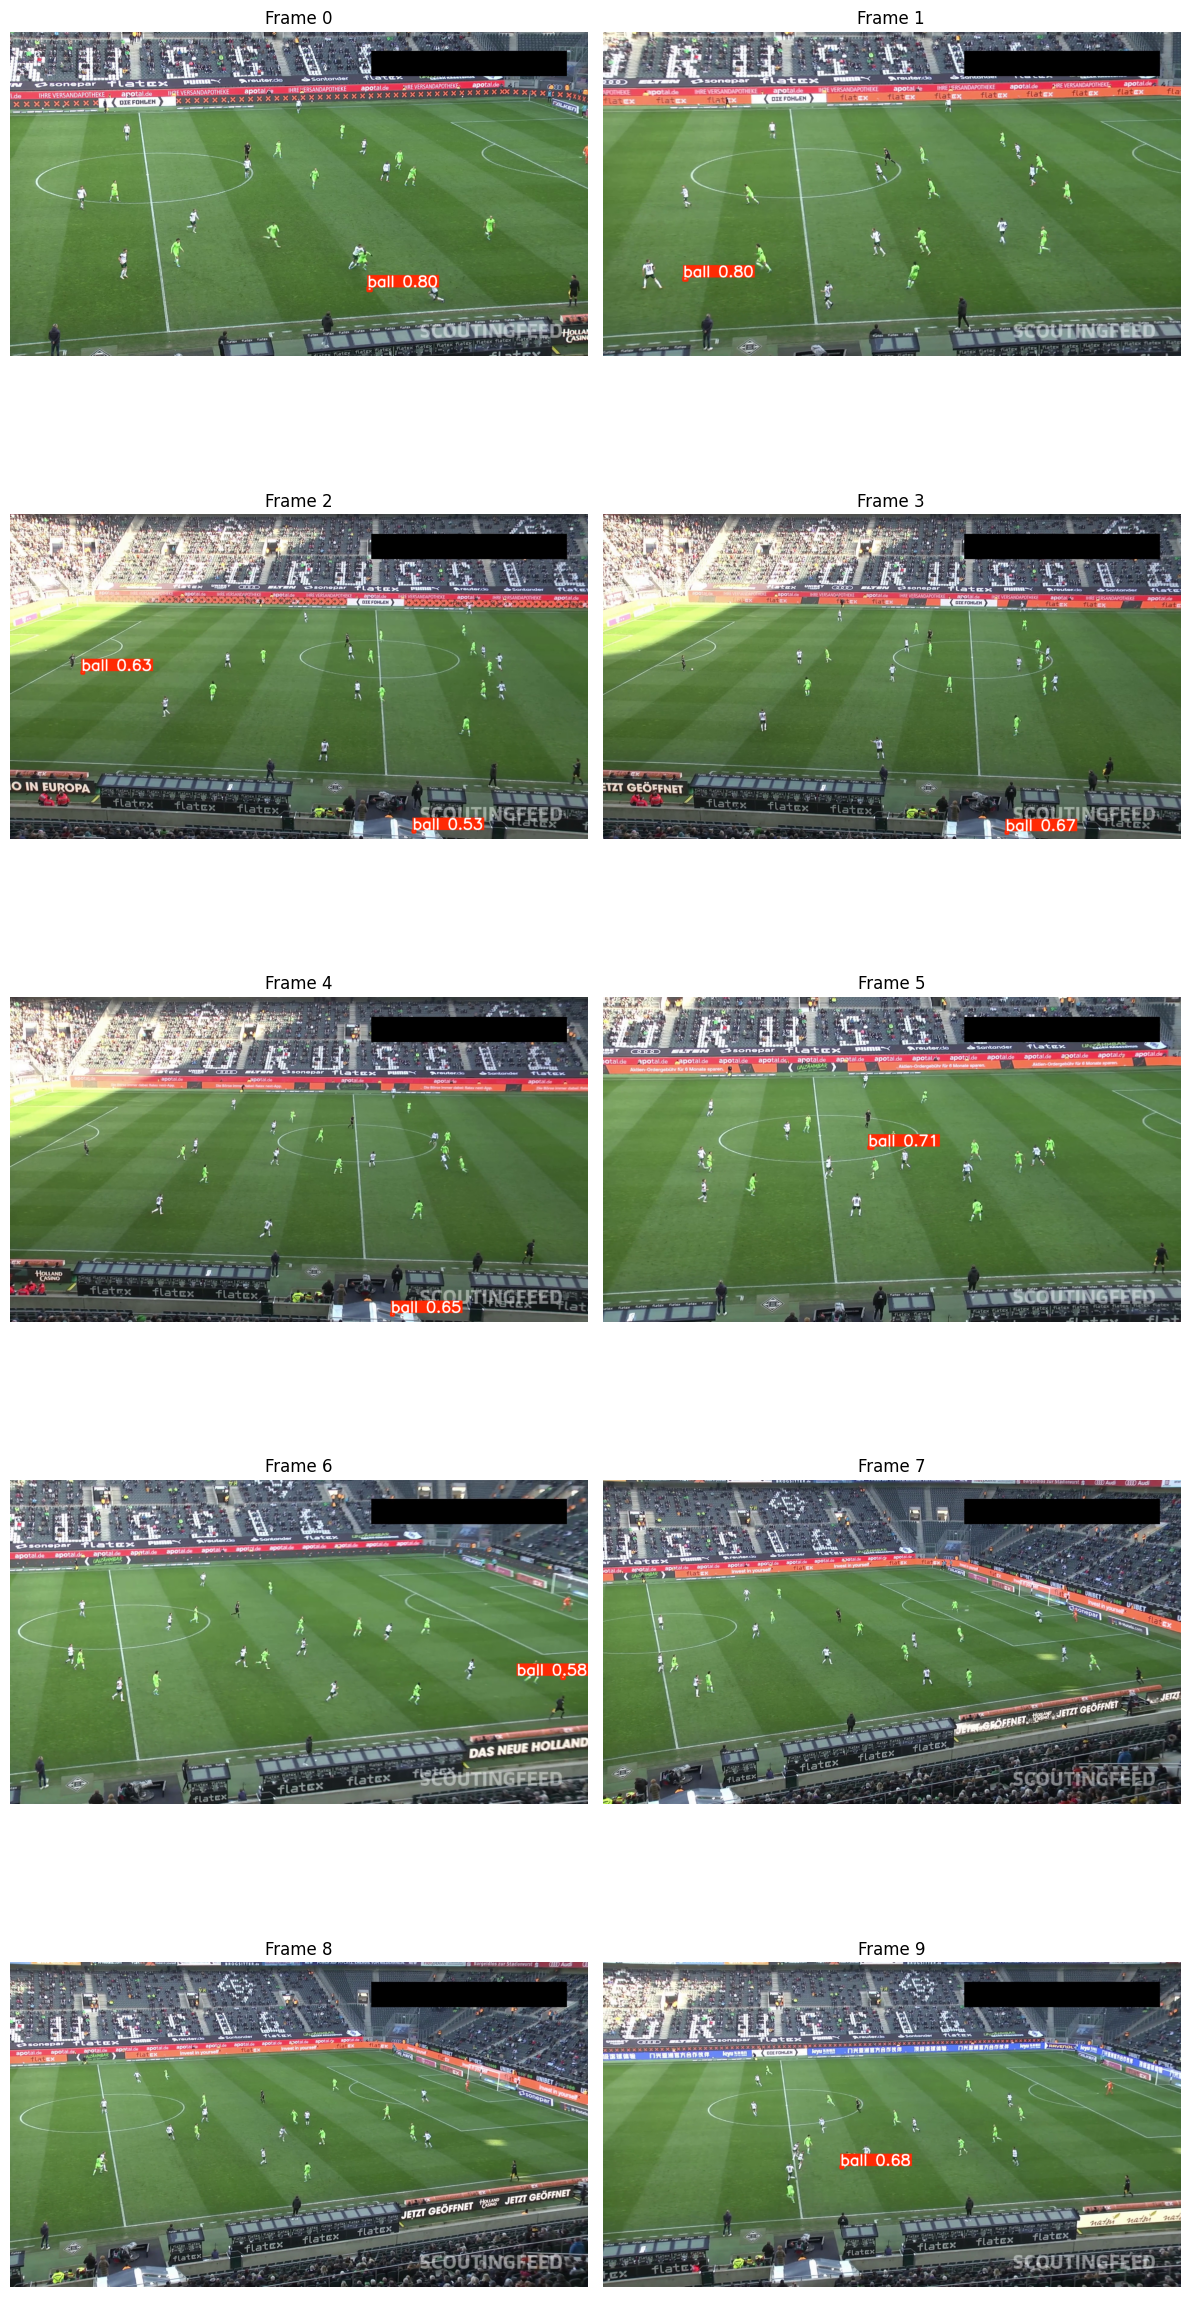

In [5]:
num_frames = len(results)

cols = 2 
rows = (num_frames + cols - 1) // cols

plt.figure(figsize=(12, rows * 5))  # tinggi otomatis ikut jumlah row

for i, result in enumerate(results):
    annotated = result.plot()
    
    plt.subplot(rows, cols, i + 1)
    plt.imshow(annotated)
    plt.title(f"Frame {i}", fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
for i, result in enumerate(results):
    print(f"Frame {i}")
    for box in result.boxes:
        print("  Conf:", float(box.conf))
        print("  Class:", int(box.cls))
        print("  BBox:", box.xyxy.tolist())
    print("------")

Frame 0
  Conf: 0.7999125123023987
  Class: 0
  BBox: [[1187.8785400390625, 851.8379516601562, 1201.84033203125, 864.3953247070312]]
------
Frame 1
  Conf: 0.8000330924987793
  Class: 0
  BBox: [[266.4578552246094, 818.4911499023438, 280.0596618652344, 829.9464111328125]]
------
Frame 2
  Conf: 0.6267195343971252
  Class: 0
  BBox: [[237.9748992919922, 521.9974365234375, 246.1061553955078, 530.4680786132812]]
  Conf: 0.528836727142334
  Class: 0
  BBox: [[1337.1229248046875, 1049.98681640625, 1346.464111328125, 1058.6318359375]]
------
Frame 3
  Conf: 0.6730553507804871
  Class: 0
  BBox: [[1337.5921630859375, 1053.4688720703125, 1346.49658203125, 1062.0428466796875]]
------
Frame 4
  Conf: 0.6529744267463684
  Class: 0
  BBox: [[1265.952392578125, 1049.994384765625, 1275.9364013671875, 1058.664794921875]]
------
Frame 5
  Conf: 0.712786078453064
  Class: 0
  BBox: [[881.9172973632812, 496.3955383300781, 898.044677734375, 504.8976745605469]]
------
Frame 6
  Conf: 0.5774146914482117
  